# Load SmartSPIM Dataset with Mask at Scale 1

Configure the dataset parameters for SmartSPIM_649103_2023-07-10_19-47-40

In [1]:
from aind_octo_data_loaders.multiscale_masked_dataloader import MultiScaleMaskedDataset

# Dataset configuration
sample_id = "SmartSPIM_649103_2023-07-10_19-47-40_stitched_2023-08-23_01-29-58"
prefix = "image_tile_fusing/OMEZarr"
channels = [
    "Ex_488_Em_525.zarr",
    "Ex_561_Em_600.zarr", 
    "Ex_647_Em_690.zarr"
]

# Choose a channel to load (let's use the first one)
channel = channels[0]  # Ex_488_Em_525.zarr

# Construct the zarr file path
# Assuming S3 bucket structure: s3://bucket-name/sample_id/prefix/channel
zarr_file = f"s3://aind-open-data/{sample_id}/{prefix}/{channel}"

# Mask file path
mask_file = f"s3://aind-msma-morphology-data/test_data/SmartSPIM/smartspim_segmentation_masks/SmartSPIM_{sample_id.split('_')[1]}/segmentation_mask.zarr"

print(f"Zarr file: {zarr_file}")
print(f"Mask file: {mask_file}")

Zarr file: s3://aind-open-data/SmartSPIM_649103_2023-07-10_19-47-40_stitched_2023-08-23_01-29-58/image_tile_fusing/OMEZarr/Ex_488_Em_525.zarr
Mask file: s3://aind-msma-morphology-data/test_data/SmartSPIM/smartspim_segmentation_masks/SmartSPIM_649103/segmentation_mask.zarr


In [16]:
# Create the MaskedZarrDataset at scale 1
dataset = MultiScaleMaskedDataset(
    sample=sample_id,
    zarr_file=zarr_file,
    mask_file=mask_file,
    scale=0,  # Scale for data
    downsampled_mask_level=2, # Scale for mask ROI selection
    volume_size=128,
    mask_threshold=0.5,
    do_pad_array=True,
    platform="SmartSPIM",
    block_prefilter=False,
    overlap_pct=0.0,
    pyramid_levels=[0, 1, 2],
    force_refilter=True,
    random_indices=True,
    minimum_occupied_volume=1.0,
)

print(f"\nDataset loaded successfully!")
print(f"Total volumes: {len(dataset)}")
item = dataset[0]
print(f"\nSample item keys: {list(item.keys())}")
print(f"Available pyramid levels: {list(item.keys())}")
print(f"Shapes of images at each level:")

item.keys()


Dataset loaded successfully!

	Using coarse prefilter from level 2 -> scale 0
	Coarse prefilter kept 37777 coarse blocks out of 120960 total.
	37777/113988 valid indices after masking.
Total volumes: 37777

Sample item keys: ['images', 'batch_resolutions', 'world_coords', 'voxel_coords', 'sample', 'platform', 'scale']
Available pyramid levels: ['images', 'batch_resolutions', 'world_coords', 'voxel_coords', 'sample', 'platform', 'scale']
Shapes of images at each level:


dict_keys(['images', 'batch_resolutions', 'world_coords', 'voxel_coords', 'sample', 'platform', 'scale'])

In [17]:
for key, value in item.items():
    print(f"  {key}: {value.shape if hasattr(value, 'shape') else type(value)}")

    if hasattr(value, 'shape'):
        print(f"  {key} shape: {value.shape} - dtype: {value.dtype} - min: {value.min()} - max: {value.max()}")

    if key in ["wolrd_coords", "batch_resolutions"]:
        print(f"  {key} sample: {value[:5]}")

  images: (3, 1, 128, 128, 128)
  images shape: (3, 1, 128, 128, 128) - dtype: float32 - min: 1.0 - max: 6542.0
  batch_resolutions: (3, 3)
  batch_resolutions shape: (3, 3) - dtype: float32 - min: 1.7999999523162842 - max: 8.0
  batch_resolutions sample: [[2.  1.8 1.8]
 [4.  3.6 3.6]
 [8.  7.2 7.2]]
  world_coords: (3, 2, 3)
  world_coords shape: (3, 2, 3) - dtype: float32 - min: 2688.0 - max: 7718.39990234375
  voxel_coords: (3, 2, 3)
  voxel_coords shape: (3, 2, 3) - dtype: int32 - min: 336 - max: 4096
  sample: <class 'str'>
  platform: <class 'str'>
  scale: <class 'int'>


In [18]:
print(f"Lazy array for level: {dataset.ms_lazy_arrays}")

Lazy array for level: {0: dask.array<getitem, shape=(3499, 8813, 7441), dtype=uint16, chunksize=(128, 128, 128), chunktype=numpy.ndarray>, 1: dask.array<getitem, shape=(1749, 4406, 3720), dtype=uint16, chunksize=(128, 128, 128), chunktype=numpy.ndarray>, 2: dask.array<getitem, shape=(874, 2203, 1860), dtype=uint16, chunksize=(128, 128, 128), chunktype=numpy.ndarray>}


In [19]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle


def draw_token_grid(ax, shape, token_size, color="cyan", alpha=0.4):
    H, W = shape

    for y in range(0, H, token_size):
        ax.plot([0, W], [y, y], color=color, alpha=alpha, linewidth=0.5)

    for x in range(0, W, token_size):
        ax.plot([x, x], [0, H], color=color, alpha=alpha, linewidth=0.5)


def show_multiscale_overlap(sample, token_size=16):
    """
    Visualization compatible with MultiScaleMaskedDataset output.
    """

    images = sample["images"]                 # (L,1,Z,Y,X)
    bboxes = sample["world_coords"]         # (L,2,3)
    resolutions = sample["batch_resolutions"] # (L,3)

    n_levels = images.shape[0]
    base_level = 0

    fig, axes = plt.subplots(1, n_levels, figsize=(6 * n_levels, 6))

    if n_levels == 1:
        axes = [axes]

    base_bbox = bboxes[base_level]

    for lvl in range(n_levels):

        ax = axes[lvl]

        img = images[lvl, 0]
        mip = img[img.shape[0] // 2]

        plow, phigh = np.percentile(mip, [1, 99])

        ax.imshow(mip, cmap="gray", vmin=plow, vmax=phigh)

        draw_token_grid(ax, mip.shape, token_size)

        bbox = bboxes[lvl]
        res = resolutions[lvl]

        # physical size of this patch
        size = bbox[1] - bbox[0]

        if lvl != base_level:

            ctx_bbox = bbox
            hr_bbox = base_bbox

            # compute intersection box in world coordinates
            inter_min = np.maximum(ctx_bbox[0], hr_bbox[0])
            inter_max = np.minimum(ctx_bbox[1], hr_bbox[1])

            # convert to voxel coordinates of this level
            box_start = (inter_min - ctx_bbox[0]) / res
            box_end = (inter_max - ctx_bbox[0]) / res

            y0 = box_start[1]
            x0 = box_start[2]

            h = box_end[1] - box_start[1]
            w = box_end[2] - box_start[2]

            rect_fill = Rectangle(
                (x0, y0),
                w,
                h,
                linewidth=0,
                facecolor="red",
                alpha=0.25,
            )

            rect_edge = Rectangle(
                (x0, y0),
                w,
                h,
                linewidth=2,
                edgecolor="red",
                facecolor="none",
                label="HR patch",
            )

            ax.add_patch(rect_fill)
            ax.add_patch(rect_edge)
            ax.legend(loc="upper right", fontsize=7)

        ax.set_title(
            f"Level {lvl}\n"
            f"Patch size (µm): "
            f"{size[0]:.1f},{size[1]:.1f},{size[2]:.1f}"
        )

        ax.set_axis_off()

    fig.suptitle(
        "Multiscale Alignment\nRed box = HR patch inside context",
        fontsize=14,
    )

    plt.tight_layout()
    plt.show()

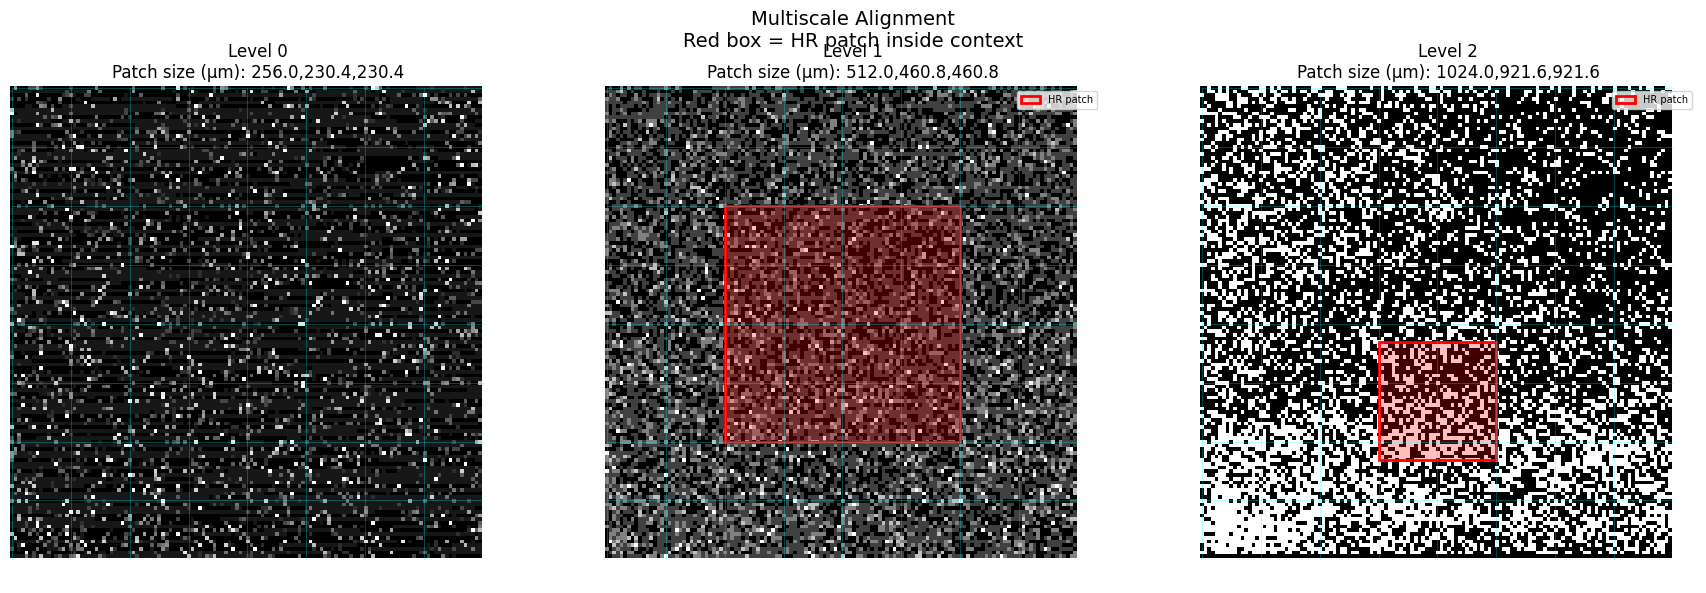

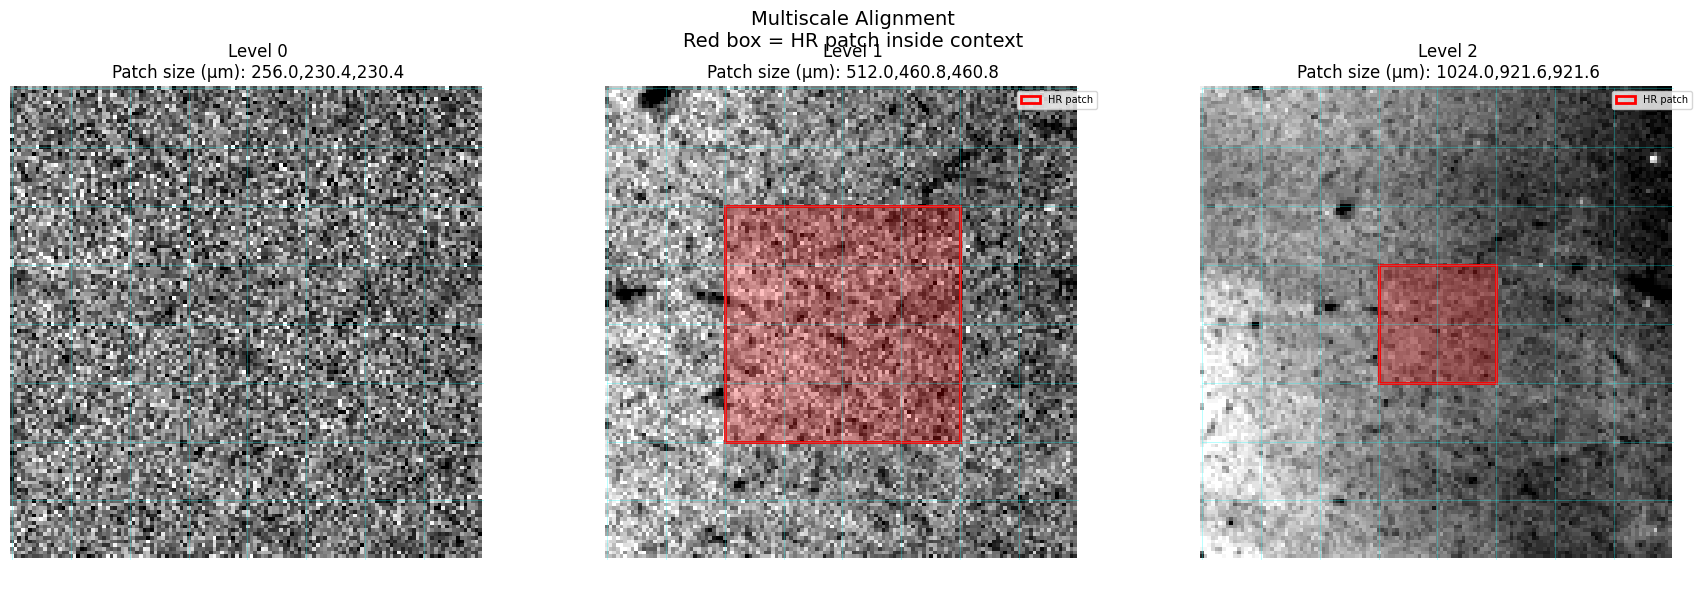

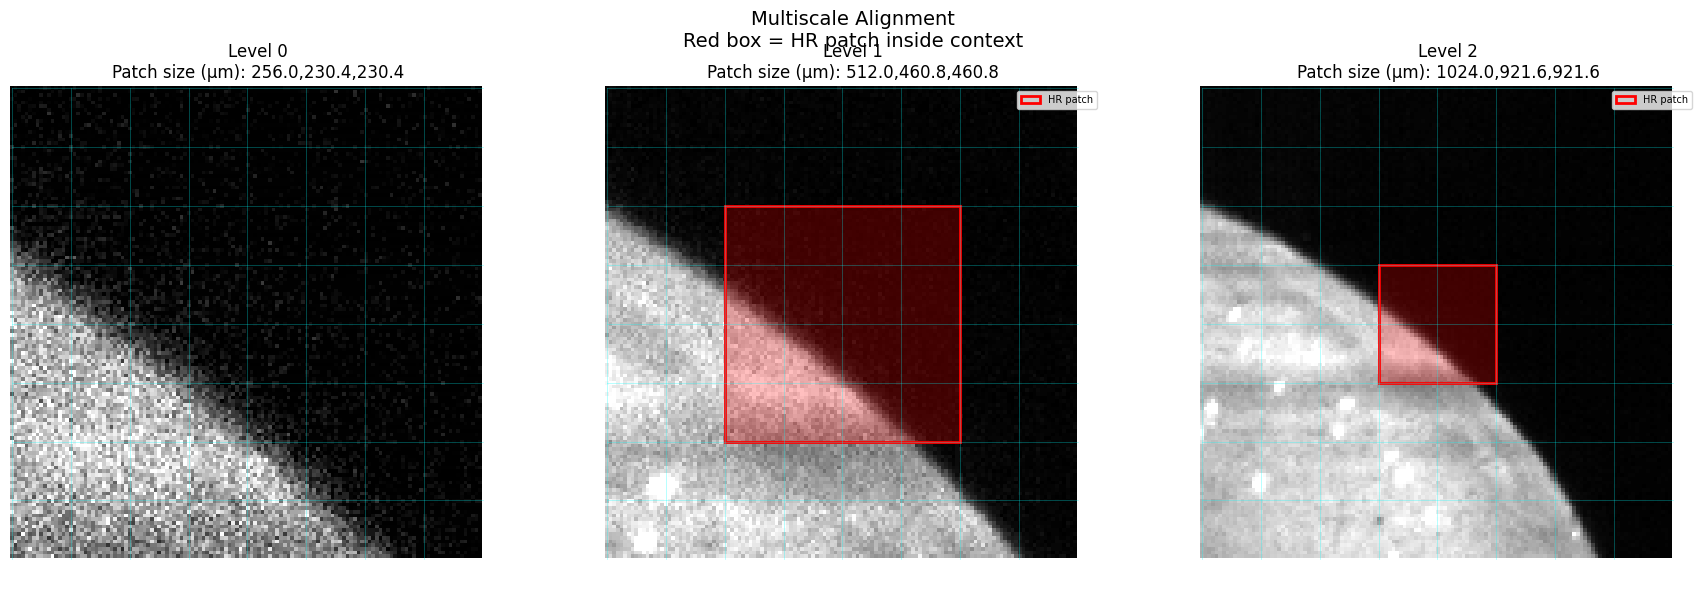

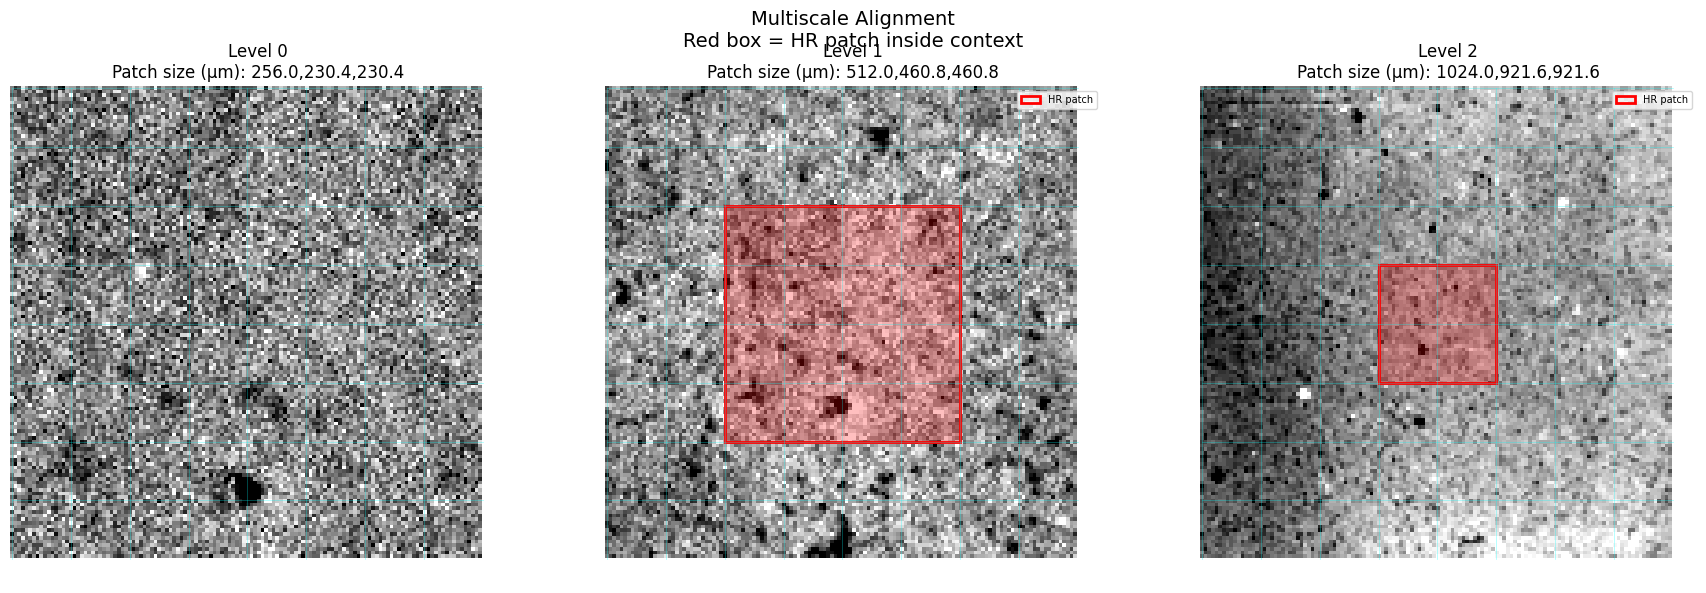

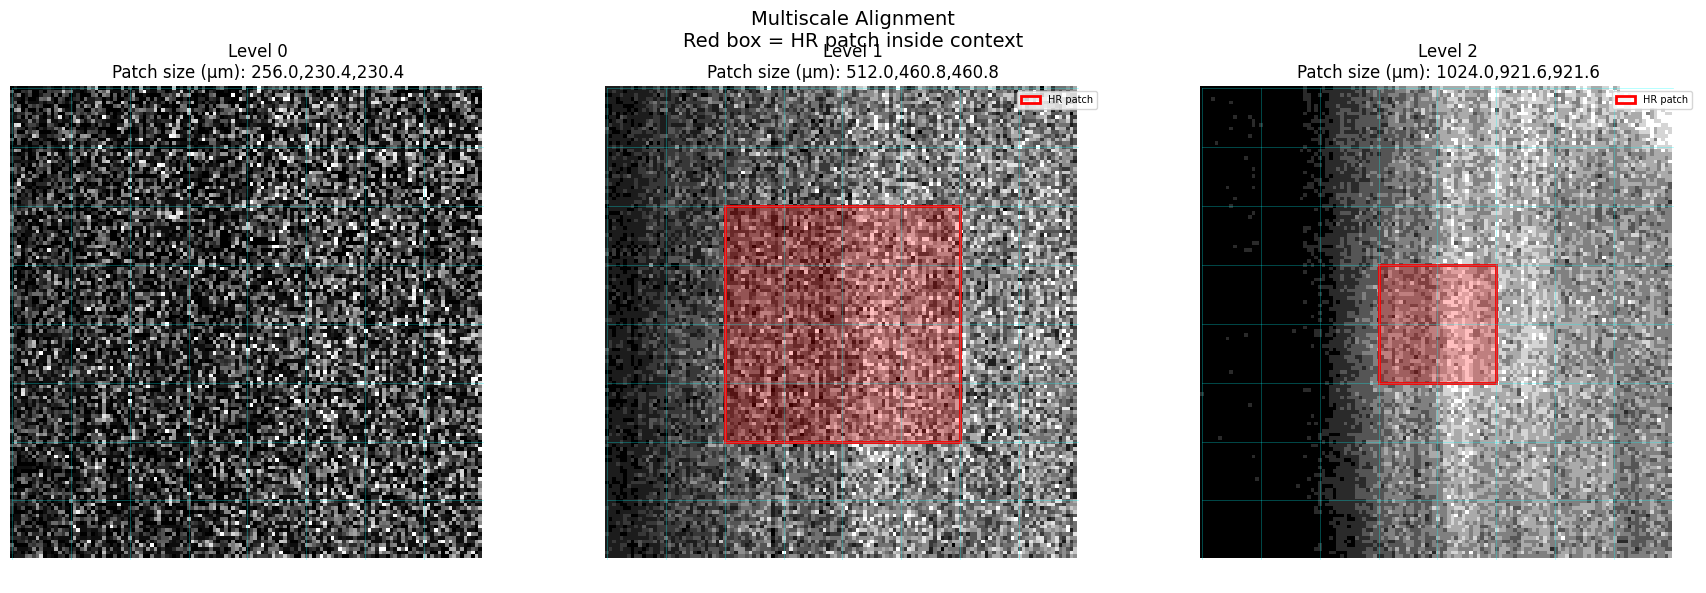

In [33]:
%matplotlib inline
plot_n_images = 5

total_coords = []
for i in range(min(plot_n_images, len(dataset))):
    item = dataset[i]

    show_multiscale_overlap(
        item, token_size=16
    )
    total_coords.append(item['voxel_coords'])


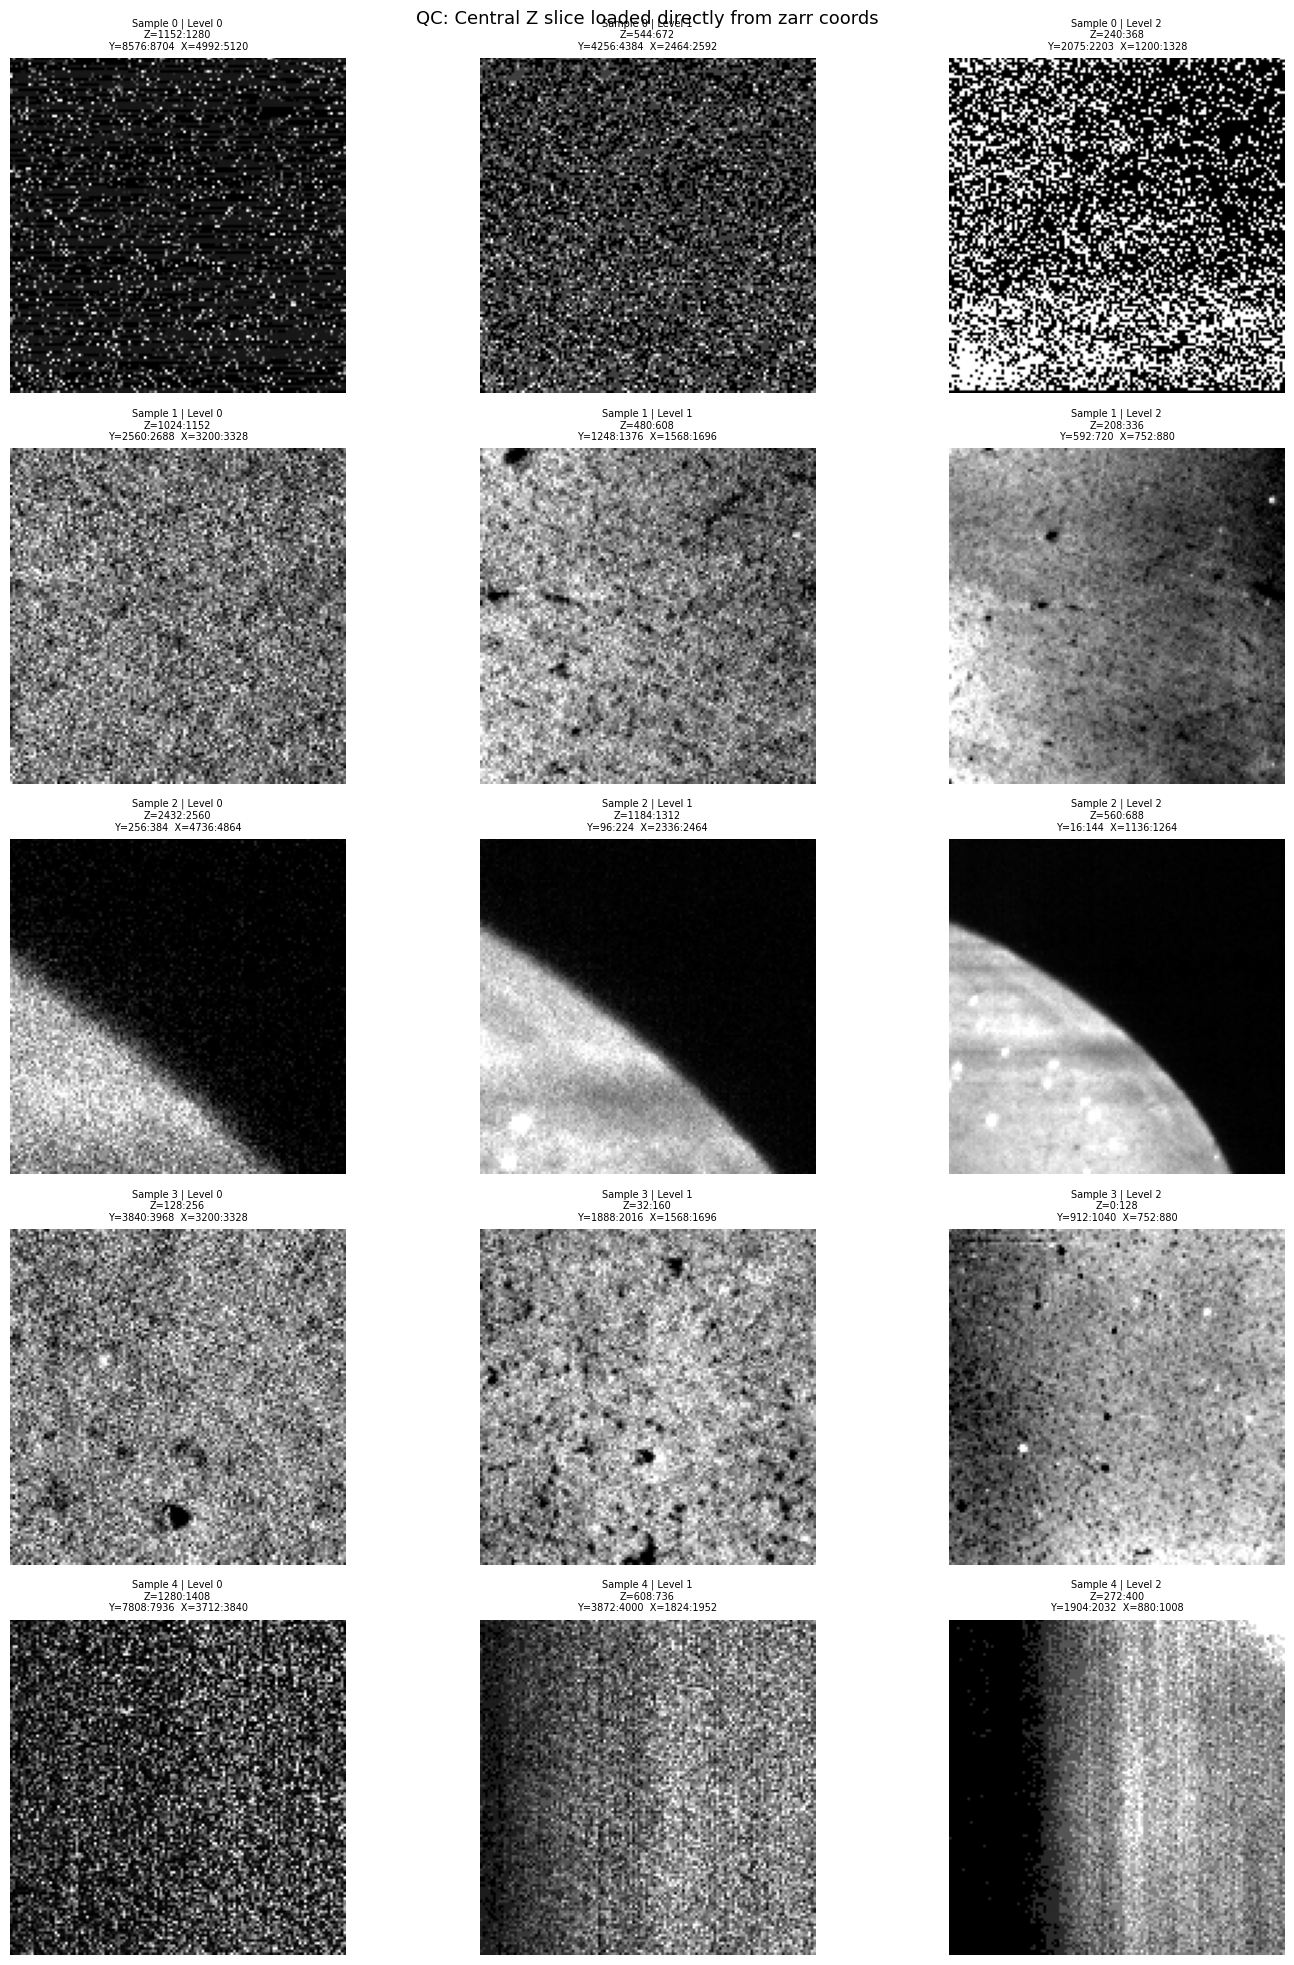

In [37]:
# QC cell: verify coords by loading central slices directly from zarr
# total_coords[i][j] = (z_slice, y_slice, x_slice) for sample i, level index j
# dataset.pyramid_levels = [0, 1, 2] — same ordering as the coord lists

levels = dataset.pyramid_levels
n_samples = len(total_coords)
n_levels = len(levels)

fig, axes = plt.subplots(n_samples, n_levels, figsize=(5 * n_levels, 4 * n_samples))
if n_samples == 1:
    axes = axes[np.newaxis, :]
if n_levels == 1:
    axes = axes[:, np.newaxis]

for i, sample_coords in enumerate(total_coords):

    for j, lvl in enumerate(levels):
        z_sl = slice(int(sample_coords[lvl][0][0]), int(sample_coords[lvl][1][0]))  # Z slice
        y_sl = slice(int(sample_coords[lvl][0][1]), int(sample_coords[lvl][1][1]))  # Y slice
        x_sl = slice(int(sample_coords[lvl][0][2]), int(sample_coords[lvl][1][2]))  # X slice
        
        arr = dataset.ms_lazy_arrays[lvl]

        # Build full slice (handle 4-D channel arrays)
        if arr.ndim == 4:
            data = arr[slice(None), z_sl, y_sl, x_sl].compute()
            data = np.squeeze(data)
        else:
            data = arr[z_sl, y_sl, x_sl].compute()

        central = data[data.shape[0] // 2]  # central Z slice

        ax = axes[i, j]
        plow, phigh = np.percentile(central, [1, 99])
        ax.imshow(central, cmap="gray", vmin=plow, vmax=phigh)
        ax.set_title(
            f"Sample {i} | Level {lvl}\n"
            f"Z={z_sl.start}:{z_sl.stop}\n"
            f"Y={y_sl.start}:{y_sl.stop}  X={x_sl.start}:{x_sl.stop}",
            fontsize=7,
        )
        ax.set_axis_off()

fig.suptitle("QC: Central Z slice loaded directly from zarr coords", fontsize=13)
plt.tight_layout()
plt.show()